# BirdCLEF 2026 — EDA

Reproducible exploratory analysis of the Pantanal dataset. Each section is independent — run from top once,
then jump around freely.

**Layout**
1. Setup
2. Soundscape inventory (labeled / partial / unlabeled / test)
3. Site distribution + (site, hour) heatmaps
4. Hour-of-day & date distributions
5. `train.csv` (focal recordings) overview
6. Class coverage matrix (sample_sub × Perch × train.csv × soundscapes)
7. The 25 zero-signal `47158sonNN` classes
8. Per-class positive counts on labeled soundscapes
9. Listen / spectrogram playground (open-ended)
10. Pseudo-label feasibility helpers


## 1. Setup

In [28]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

DATA = Path("data")
assert DATA.exists(), f"Run from repo root. Got cwd={Path.cwd()}"


In [29]:
# Repo-side helpers
from birdclef.data.soundscapes import (
    parse_fname, load_soundscape_meta, list_soundscape_files,
    list_unlabeled_soundscape_files, list_test_files,
    primary_labels, load_taxonomy,
)
from birdclef.data.splits import load_folds


## 2. Soundscape inventory

Three buckets:
- **labeled**   = file has all 12 windows labeled in `train_soundscapes_labels.csv` (`fully_labeled=True`)
- **partial**   = file appears in the labels CSV but with <12 labeled windows
- **unlabeled** = file is on disk but has zero rows in the labels CSV


In [30]:
all_paths = list_soundscape_files(labeled_only=False)
df_all = pd.DataFrame([parse_fname(p.name) | {"filename": p.name} for p in all_paths])

sc_meta = load_soundscape_meta()
labeled_files = set(sc_meta.query("fully_labeled")["filename"])
csv_files     = set(sc_meta["filename"])
df_all["status"] = np.where(
    df_all["filename"].isin(labeled_files), "labeled",
    np.where(df_all["filename"].isin(csv_files), "partial", "unlabeled"),
)
print(df_all["status"].value_counts().to_string())
print(f"\nTotal train_soundscape files = {len(df_all)}")

# Atomic-label counts. Note: raw CSV `primary_label` is semicolon-joined multi-labels —
# always derive distinct labels from sc_meta.label_list, not raw CSV.
lbls_any  = set().union(*sc_meta["label_list"])
lbls_full = set().union(*sc_meta.query("fully_labeled")["label_list"])
print(f"distinct atomic labels in soundscapes (any rows)      = {len(lbls_any)}")
print(f"distinct atomic labels in soundscapes (fully_labeled) = {len(lbls_full)}")


status
unlabeled    10592
labeled         59
partial          7

Total train_soundscape files = 10658
distinct atomic labels in soundscapes (any rows)      = 75
distinct atomic labels in soundscapes (fully_labeled) = 71


## 3. Site distribution

In [31]:
sd = df_all.pivot_table(index="site", columns="status",
                        values="filename", aggfunc="count", fill_value=0)
sd["total"] = sd.sum(axis=1)
sd["lab_share"] = (sd.get("labeled", 0) / sd["total"]).round(3)
sd = sd.sort_values("total", ascending=False)
sd


status,labeled,partial,unlabeled,total,lab_share
site,,,,,
S22,39,1,3343,3383,0.012
S02,0,0,2505,2505,0.000
S01,0,0,2341,2341,0.000
S13,2,0,1871,1873,0.001
S19,3,0,73,76,0.039
S18,1,1,52,54,0.019
S06,0,0,54,54,0.000
S07,0,0,52,52,0.000
S16,0,0,48,48,0.000


In [32]:
labeled_sites   = set(df_all[df_all.status=="labeled"]["site"])
unlabeled_sites = set(df_all[df_all.status=="unlabeled"]["site"])
print(f"Sites with ANY labeled file:  {sorted(labeled_sites)}  (n={len(labeled_sites)})")
print(f"Sites with ZERO labeled file: {sorted(unlabeled_sites - labeled_sites)}  "
      f"(n={len(unlabeled_sites - labeled_sites)})")


Sites with ANY labeled file:  ['S03', 'S08', 'S13', 'S15', 'S18', 'S19', 'S22', 'S23']  (n=8)
Sites with ZERO labeled file: ['S01', 'S02', 'S04', 'S05', 'S06', 'S07', 'S09', 'S10', 'S11', 'S12', 'S14', 'S16', 'S17', 'S20', 'S21']  (n=15)


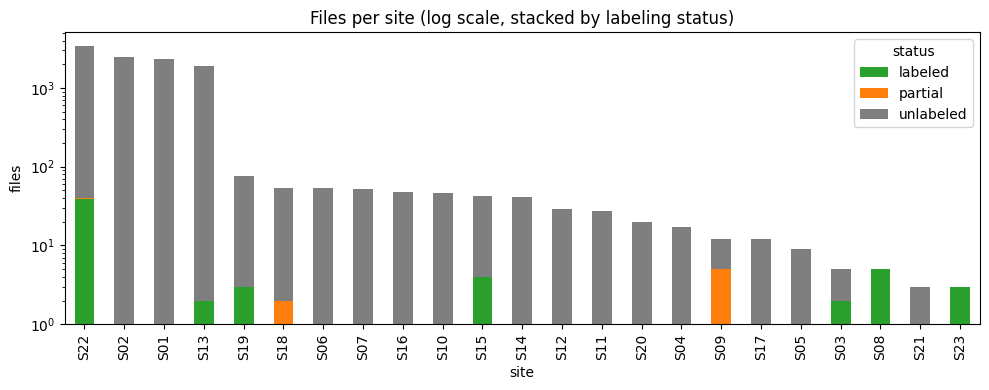

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
sd_plot = sd.drop(columns=["total", "lab_share"])
sd_plot.plot(kind="bar", stacked=True, ax=ax,
             color={"labeled":"tab:green","partial":"tab:orange","unlabeled":"tab:gray"})
ax.set_yscale("log")
ax.set_title("Files per site (log scale, stacked by labeling status)")
ax.set_xlabel("site"); ax.set_ylabel("files")
plt.tight_layout(); plt.show()


## 4. Hour-of-day and date coverage

In [34]:
hd = df_all.pivot_table(index="hour_utc", columns="status",
                        values="filename", aggfunc="count", fill_value=0)
hd["total"] = hd.sum(axis=1)
hd["lab_share"] = (hd.get("labeled", 0) / hd["total"]).round(3)
hd


status,labeled,partial,unlabeled,total,lab_share
hour_utc,,,,,
0,2,6,772,780,0.003
1,4,1,1112,1117,0.004
2,5,0,1026,1031,0.005
3,4,0,992,996,0.004
4,3,0,263,266,0.011
5,0,0,6,6,0.000
6,4,0,91,95,0.042
7,3,0,6,9,0.333
8,0,0,10,10,0.000


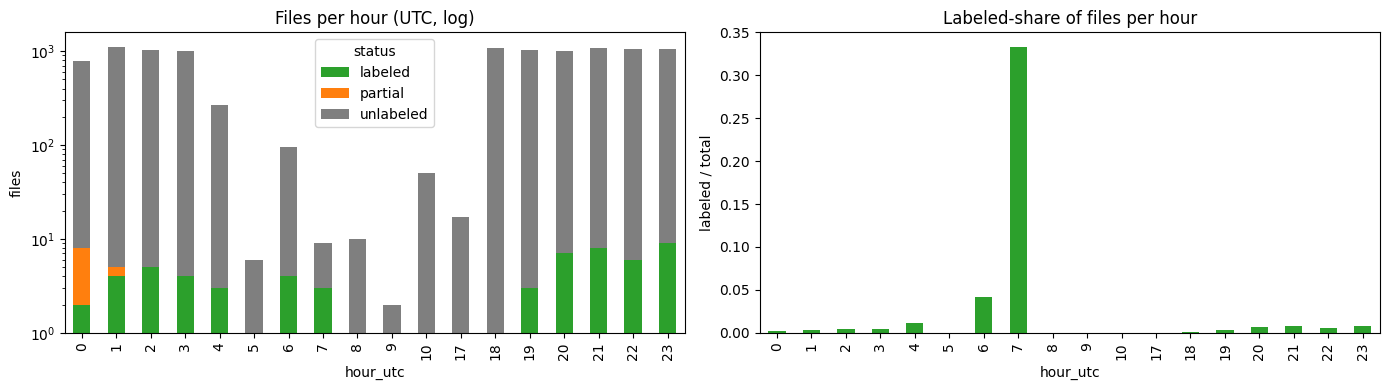

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hd.drop(columns=["total","lab_share"]).plot(kind="bar", stacked=True, ax=axes[0],
    color={"labeled":"tab:green","partial":"tab:orange","unlabeled":"tab:gray"})
axes[0].set_yscale("log"); axes[0].set_title("Files per hour (UTC, log)")
axes[0].set_xlabel("hour_utc"); axes[0].set_ylabel("files")

share = (hd.get("labeled",0) / hd["total"]).fillna(0)
share.plot(kind="bar", ax=axes[1], color="tab:green")
axes[1].set_title("Labeled-share of files per hour")
axes[1].set_xlabel("hour_utc"); axes[1].set_ylabel("labeled / total")
plt.tight_layout(); plt.show()


In [36]:
def _date_summary(df, name):
    d = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce").dropna()
    if not len(d): return None
    return {"status": name, "n": len(d), "unique_dates": d.nunique(),
            "min": d.min().date(), "max": d.max().date()}
rows = [_date_summary(df_all[df_all.status==s], s) for s in ["labeled","partial","unlabeled"]]
pd.DataFrame([r for r in rows if r])


,status,n,unique_dates,min,max
0,labeled,59,46,2021-10-26,2025-06-17
1,partial,7,5,2021-10-16,2025-08-31
2,unlabeled,10592,772,2014-01-07,2025-11-29


In [37]:
heat = df_all[df_all.status=="labeled"].pivot_table(
    index="site", columns="hour_utc", values="filename", aggfunc="count", fill_value=0)
print("LABELED files per (site, hour):")
heat


LABELED files per (site, hour):


hour_utc,0,1,2,3,4,6,7,18,19,20,21,22,23
site,,,,,,,,,,,,,
S03,0,0,0,0,0,0,0,0,0,1,0,0,1
S08,0,0,0,2,0,0,3,0,0,0,0,0,0
S13,0,0,0,0,0,0,0,0,0,0,1,0,1
S15,0,0,0,0,0,4,0,0,0,0,0,0,0
S18,0,0,0,0,0,0,0,0,0,0,0,1,0
S19,0,0,0,0,0,0,0,0,2,0,1,0,0
S22,2,4,5,1,1,0,0,1,1,6,6,5,7
S23,0,0,0,1,2,0,0,0,0,0,0,0,0


In [38]:
heat_un = df_all[df_all.status=="unlabeled"].pivot_table(
    index="site", columns="hour_utc", values="filename", aggfunc="count", fill_value=0)
print("UNLABELED files per (site, hour):")
heat_un


UNLABELED files per (site, hour):


hour_utc,0,1,2,3,4,5,6,7,8,9,10,17,18,19,20,21,22,23
site,,,,,,,,,,,,,,,,,,
S01,157,260,236,227,56,0,0,0,0,0,0,1,245,216,223,234,243,243
S02,187,275,247,234,61,0,0,0,0,0,0,1,263,226,246,256,255,254
S03,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0
S04,3,0,0,0,3,0,0,0,9,0,0,2,0,0,0,0,0,0
S05,0,0,0,5,0,0,0,0,0,0,0,4,0,0,0,0,0,0
S06,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,31,0,8
S07,15,0,0,15,0,0,0,0,0,0,0,0,0,0,0,7,15,0
S09,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
S10,0,0,0,0,0,0,0,0,0,0,46,0,0,0,0,0,0,0


## 5. `train.csv` (focal recordings) overview

In [39]:
train_df = pd.read_csv(DATA/"train.csv")
print(f"rows={len(train_df)}  unique_classes={train_df['primary_label'].nunique()}")
print(f"unique authors={train_df['author'].nunique()}  collections={train_df['collection'].unique().tolist()}")
train_df.head(3)


rows=35549  unique_classes=206
unique authors=4017  collections=['iNat', 'XC']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


recordings per class — median=125.0, mean=172.6, max=499, min=1
  classes with <5 recordings:  14
  classes with <20 recordings: 36
  classes with >=100:          124


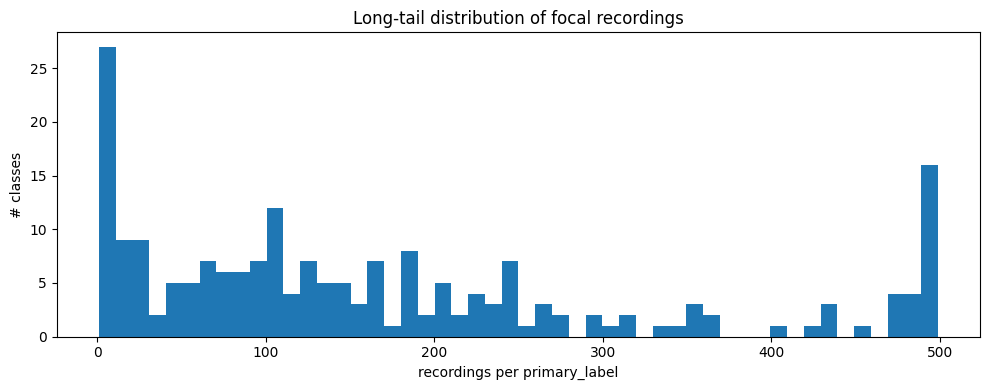

In [40]:
counts = train_df["primary_label"].value_counts()
print(f"recordings per class — median={counts.median()}, mean={counts.mean():.1f}, "
      f"max={counts.max()}, min={counts.min()}")
print(f"  classes with <5 recordings:  {(counts<5).sum()}")
print(f"  classes with <20 recordings: {(counts<20).sum()}")
print(f"  classes with >=100:          {(counts>=100).sum()}")

fig, ax = plt.subplots(figsize=(10,4))
ax.hist(counts.values, bins=50)
ax.set_xlabel("recordings per primary_label"); ax.set_ylabel("# classes")
ax.set_title("Long-tail distribution of focal recordings")
plt.tight_layout(); plt.show()


In [41]:
# class_name (Aves / Insecta / Amphibia / Mammalia / Reptilia) breakdown
# train.csv already carries a class_name column.
tax = load_taxonomy()
print("Recordings by class_name:")
print(train_df["class_name"].value_counts().to_string())
print()
print("Unique species per class_name:")
print(train_df.groupby("class_name")["primary_label"].nunique().to_string())


Recordings by class_name:
class_name
Aves        34799
Amphibia      451
Insecta       199
Mammalia       99
Reptilia        1

Unique species per class_name:
class_name
Amphibia     32
Aves        162
Insecta       3
Mammalia      8
Reptilia      1


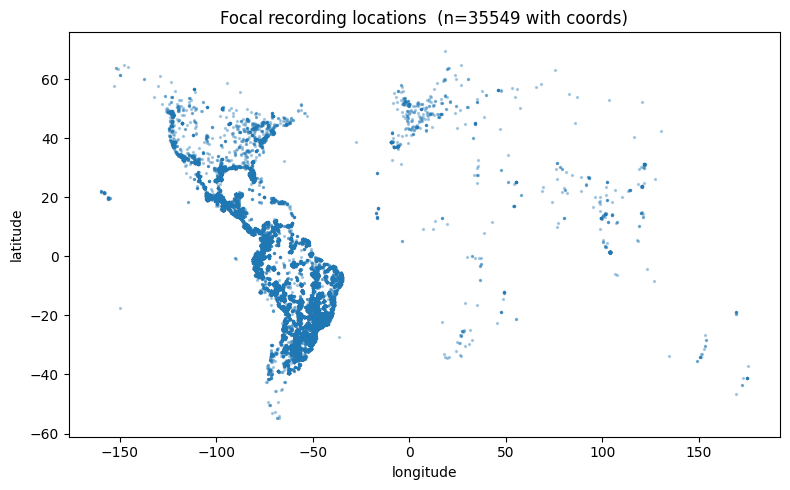

In [42]:
# Geographic distribution of the focal recordings (lat/lon)
loc = train_df.dropna(subset=["latitude","longitude"])
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(loc["longitude"], loc["latitude"], s=2, alpha=0.3)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"Focal recording locations  (n={len(loc)} with coords)")
plt.tight_layout(); plt.show()


## 6. Class coverage matrix

For each of the 234 sample-submission classes, where is the training signal?
- **Perch direct**  — Perch model has the species in its 6,000-class head
- **Perch proxy**   — same genus is in Perch (reasonable transfer for Insecta/Amphibia/Aves)
- **train.csv**     — at least one focal recording exists
- **soundscape**    — at least one positive in the 59 labeled soundscapes


In [43]:
from birdclef.models.perch import build_label_mapping

labels = primary_labels()
N = len(labels)
mapping = build_label_mapping()
direct  = set(mapping["mapped_pos"].tolist())
proxy   = set(int(k) for k in mapping["proxy_map"].keys())
perch_any = direct | proxy

train_classes = set(train_df["primary_label"].unique())
# CSV `primary_label` cells are semicolon-joined multi-labels (e.g. "rubthr1;47158son01") —
# read the union of *atomic* labels via sc_meta.label_list, NOT the raw CSV column.
sc_classes = set()
for L in sc_meta["label_list"]:
    sc_classes.update(L)
sc_classes_full = set()
for L in sc_meta.query("fully_labeled")["label_list"]:
    sc_classes_full.update(L)
print(f"distinct atomic labels in soundscapes (any file)        : {len(sc_classes)}")
print(f"distinct atomic labels in soundscapes (fully_labeled)   : {len(sc_classes_full)}")

lpos = {lb: i for i, lb in enumerate(labels)}
train_pos = {lpos[lb] for lb in train_classes if lb in lpos}
sc_pos    = {lpos[lb] for lb in sc_classes if lb in lpos}

cov = pd.DataFrame({"primary_label": labels})
cov["pos"]            = np.arange(N)
cov["perch_direct"]   = cov["pos"].isin(direct)
cov["perch_proxy"]    = cov["pos"].isin(proxy)
cov["perch_any"]      = cov["pos"].isin(perch_any)
cov["in_train_csv"]   = cov["pos"].isin(train_pos)
cov["in_soundscape"]  = cov["pos"].isin(sc_pos)
cov["any_signal"]     = cov[["perch_any","in_train_csv","in_soundscape"]].any(axis=1)
cov = cov.merge(tax[["primary_label","class_name","scientific_name"]], on="primary_label", how="left")
cov.head()


distinct atomic labels in soundscapes (any file)        : 75
distinct atomic labels in soundscapes (fully_labeled)   : 71


,primary_label,pos,perch_direct,perch_proxy,perch_any,in_train_csv,in_soundscape,any_signal,class_name,scientific_name
0,1161364,0,True,False,True,True,False,True,Insecta,Guyalna cuta
1,116570,1,False,False,False,True,True,True,Reptilia,Caiman yacare
2,1176823,2,True,False,True,True,False,True,Amphibia,Leptodactylus luctator
3,1491113,3,False,True,True,False,True,True,Amphibia,Adenomera guarani
4,1595929,4,False,True,True,True,False,True,Amphibia,Lysapsus limellum


In [45]:
print("=== Class coverage summary ===")
print(f"Total classes                            : {N}")
print(f"Perch direct                             : {cov['perch_direct'].sum()}")
print(f"Perch direct + proxy                     : {cov['perch_any'].sum()}")
print(f"In train.csv (focal)                     : {cov['in_train_csv'].sum()}")
print(f"In soundscape labels                     : {cov['in_soundscape'].sum()}")
print(f"In Perch ∪ train.csv                     : {(cov['perch_any'] | cov['in_train_csv']).sum()}")
print(f"In Perch ∪ soundscape                    : {(cov['perch_any'] | cov['in_soundscape']).sum()}")
print(f"In Perch ∪ train.csv ∪ soundscape        : {(cov['perch_any'] | cov['in_train_csv'] | cov['in_soundscape']).sum()}")
print(f"In train.csv ∪ soundscape                : {(cov['in_train_csv'] | cov['in_soundscape']).sum()}")
print(f"In ANY source (any_signal)               : {cov['any_signal'].sum()}")
print(f"ZERO signal anywhere                     : {(~cov['any_signal']).sum()}")

=== Class coverage summary ===
Total classes                            : 234
Perch direct                             : 203
Perch direct + proxy                     : 206
In train.csv (focal)                     : 206
In soundscape labels                     : 75
In Perch ∪ train.csv                     : 209
In Perch ∪ soundscape                    : 233
In Perch ∪ train.csv ∪ soundscape        : 234
In train.csv ∪ soundscape                : 234
In ANY source (any_signal)               : 234
ZERO signal anywhere                     : 0


In [ ]:
# Cross-tab Perch vs train.csv
both       = perch_any & train_pos
perch_only = perch_any - train_pos
focal_only = train_pos - perch_any
neither    = set(range(N)) - (perch_any | train_pos)
print(f"in BOTH Perch and train.csv  : {len(both):3d}  -> strongest signal")
print(f"in Perch ONLY                : {len(perch_only):3d}")
print(f"in train.csv ONLY            : {len(focal_only):3d}  -> only learnable from focal")
print(f"in NEITHER                   : {len(neither):3d}")
print()
print("'Focal-only' classes (Perch can't see them):")
print(cov.loc[cov["pos"].isin(focal_only), ["primary_label","class_name","scientific_name"]].to_string(index=False))


## 7. The 25 zero-signal `47158sonNN` classes

iNat 47158 = the entire class **Insecta**. The `sonNN` suffixes are sonotypes —
distinct call types an annotator could distinguish but couldn't ID to species.
By construction there are no external recordings labeled with these IDs.

How much *soundscape* signal exists for them?


In [ ]:
sonotype_lbls = sorted([lb for lb in labels if lb.startswith("47158son")])
print(f"sonotype classes: {len(sonotype_lbls)}")

# IMPORTANT: CSV `primary_label` is semicolon-joined; sonotypes appear ONLY in multi-label
# combos (e.g. "22973;47158son25;65380"), never standalone. Always use sc_meta.label_list,
# which has been split via union_labels — exact-string matching on the raw CSV silently
# returns zero for every sonotype.
rows = []
for lb in sonotype_lbls:
    mask_any  = sc_meta["label_list"].apply(lambda L: lb in L)
    mask_full = sc_meta.query("fully_labeled")["label_list"].apply(lambda L: lb in L)
    n_windows_any  = int(mask_any.sum())
    n_files_any    = int(sc_meta.loc[mask_any, "filename"].nunique())
    n_windows_full = int(mask_full.sum())
    n_files_full   = int(sc_meta.query("fully_labeled").loc[mask_full, "filename"].nunique())
    rows.append({
        "label": lb,
        "windows_any":  n_windows_any,
        "files_any":    n_files_any,
        "windows_full": n_windows_full,
        "files_full":   n_files_full,
    })
per_son = pd.DataFrame(rows).set_index("label").sort_values("windows_full", ascending=False)
per_son


In [ ]:
print(f"sonotype positives in fully_labeled files:")
print(f"  classes with >=20 positive windows : {(per_son['windows_full']>=20).sum()}  (plausibly trainable)")
print(f"  classes with >=5 positive windows  : {(per_son['windows_full']>=5).sum()}")
print(f"  classes with 0 positive windows    : {(per_son['windows_full']==0).sum()}  (unrecoverable)")
print(f"  total sonotype positive windows in fully_labeled : {per_son['windows_full'].sum()}")


## 8. Per-class positive counts on the 59 labeled soundscapes

In [ ]:
from birdclef.data.soundscapes import build_label_matrix, label_to_idx
sc_full = sc_meta.query("fully_labeled").reset_index(drop=True)
Y = build_label_matrix(sc_full)
idx2lbl = {v:k for k,v in label_to_idx().items()}
pos_per_class = Y.sum(axis=0)
class_support = pd.DataFrame({
    "primary_label": [idx2lbl[i] for i in range(len(pos_per_class))],
    "pos_windows":   pos_per_class,
})
class_support = class_support.merge(tax[["primary_label","class_name"]], on="primary_label", how="left")
class_support["pos_files"] = [
    sc_full[sc_full["label_list"].apply(lambda L: idx2lbl[i] in L)]["filename"].nunique()
    for i in range(len(pos_per_class))
]
class_support.sort_values("pos_windows", ascending=False).head(20)


In [ ]:
print("Distribution of class support on the 59 labeled soundscapes:")
print(f"  classes with 0 positive windows : {(class_support['pos_windows']==0).sum()}")
print(f"  with 1-4 positive windows       : {((class_support['pos_windows']>=1) & (class_support['pos_windows']<5)).sum()}")
print(f"  with 5-19 positive windows      : {((class_support['pos_windows']>=5) & (class_support['pos_windows']<20)).sum()}")
print(f"  with 20+ positive windows       : {(class_support['pos_windows']>=20).sum()}")


In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(class_support["pos_windows"], bins=50)
ax.set_xlabel("positive windows in 59 labeled soundscapes")
ax.set_ylabel("# classes"); ax.set_title("Soundscape support histogram")
plt.tight_layout(); plt.show()


## 9. Listen / spectrogram playground (open-ended)

Pick any soundscape file or focal recording and inspect the audio + label structure.
Modify `TARGET_FILE` and re-run.


In [ ]:
import soundfile as sf
import IPython.display as ipd

# pick a labeled soundscape with rich species content
TARGET_FILE = sc_full.groupby("filename").size().sort_values(ascending=False).index[0]
print(f"TARGET_FILE = {TARGET_FILE}")

audio_path = DATA/"train_soundscapes"/TARGET_FILE
y, sr = sf.read(str(audio_path), dtype="float32")
print(f"  duration={len(y)/sr:.1f}s  sr={sr}")

rows = sc_full[sc_full["filename"]==TARGET_FILE][["start","end","label_list","site","hour_utc"]]
display(rows)
ipd.Audio(str(audio_path))


In [ ]:
# Mel spectrogram of the file
import librosa, librosa.display
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512, fmax=sr//2)
mdb = librosa.power_to_db(mel, ref=np.max)
fig, ax = plt.subplots(figsize=(14,4))
img = librosa.display.specshow(mdb, sr=sr, hop_length=512, x_axis="time", y_axis="mel", ax=ax, fmax=sr//2)
fig.colorbar(img, ax=ax, format="%+2.f dB")
ax.set_title(f"{TARGET_FILE}  —  fully_labeled={TARGET_FILE in labeled_files}")
plt.tight_layout(); plt.show()


In [ ]:
# Pick a focal recording for any class you want to inspect
TARGET_CLASS = "rubthr1"   # ← change me
samples = train_df[train_df["primary_label"]==TARGET_CLASS].head(3)
for _, row in samples.iterrows():
    fp = DATA/"train_audio"/row["filename"]
    if not fp.exists():
        print(f"missing: {fp}"); continue
    y, sr = sf.read(str(fp), dtype="float32")
    print(f"{row['filename']}  ({len(y)/sr:.1f}s)  rating={row['rating']}  author={row['author']}")
    display(ipd.Audio(str(fp)))


## 10. Pseudo-label feasibility helpers

Two questions to inform the pseudo-labeling strategy:
1. How many unlabeled soundscape-windows would survive a high-confidence Perch threshold per site?
2. Are the unlabeled sites' acoustic characteristics similar to the labeled ones (PCA on Perch embeddings)?

These need the cached Perch arrays — only run if `data/perch/` (or the new cache) is built.


In [ ]:
# Cheap proxy: how many unlabeled WINDOWS (×12 per file) per site would pseudo-labeling target?
budget = (
    df_all.groupby(["site","status"]).size().unstack(fill_value=0)
)
budget["unlabeled_windows"] = budget.get("unlabeled", 0) * 12
budget["labeled_windows"]   = budget.get("labeled",   0) * 12
budget["leverage"] = (budget["unlabeled_windows"] /
                      (budget["labeled_windows"].replace(0, np.nan))).round(1)
budget.sort_values("unlabeled_windows", ascending=False)


In [ ]:
# Optional: PCA on Perch embeddings, colour-coded by site (labeled vs unlabeled)
# Heavy — only enable if you have built the full Perch cache.
RUN_PCA = False
if RUN_PCA:
    from birdclef.train.train_ssm_head import load_perch_cache
    from sklearn.decomposition import PCA
    cache = load_perch_cache()
    file_emb = cache.emb.reshape(-1, 12, cache.emb.shape[1]).mean(axis=1)
    file_meta = cache.meta.drop_duplicates("filename").reset_index(drop=True)
    pca = PCA(n_components=2).fit_transform(file_emb)
    fig, ax = plt.subplots(figsize=(9,7))
    for s in sorted(file_meta["site"].unique()):
        m = file_meta["site"]==s
        ax.scatter(pca[m,0], pca[m,1], s=6, alpha=0.4, label=s)
    ax.legend(bbox_to_anchor=(1.02,1), fontsize=8, ncol=2)
    ax.set_title("PCA(2) of file-mean Perch embeddings")
    plt.tight_layout(); plt.show()


---
## Notes for further research

- **Site domain shift**: the 15 sites with zero labels (S01, S02, S04–S07, S09–S12, S14, S16, S17, S20, S21)
  are where pseudo-labeling has the most to lose. Compare their unlabeled-Perch-embedding distribution to the
  8 labeled sites (PCA cell above). If they cluster separately, pseudo-labels there will be untrustworthy.
- **Date shift**: unlabeled spans 2014–2025, labeled spans 2021–2025. Older recordings might be collected
  on different equipment.
- **Hour gap**: hours 8–17 UTC are sparse in both labeled and unlabeled. If test prevalence is uniform across
  the day, this is a coverage problem; if test is also nocturnal, it's not.
- **Sonotypes**: the 25 `47158sonNN` classes are unrecoverable from external data, but most DO have
  positives in the 59 labeled soundscapes (Section 7) — they're plausible SED-head targets even
  without focal recordings. CSV uses semicolon-joined multi-labels, always read via `sc_meta.label_list`.
- **Long tail**: 36 of 206 covered classes have <20 focal recordings. Mixup and heavy augmentation matter
  more for these than architecture choice.
